# CritiqueBrainz Reviews

Fetches English release-group reviews from the [CritiqueBrainz API](https://critiquebrainz.readthedocs.io/api/endpoints.html).

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from textblob import TextBlob
from tqdm.auto import tqdm

import itables
# itables.init_notebook_mode()

In [2]:
API_ENDPOINT = "https://critiquebrainz.org/ws/1"
REVIEWS_PER_REQUEST = 100
DATA_DIR = Path("../datasets")

ENTITY_TYPE = "release_group" # MusicBrainz-backed entity that merges difference releases of the same album into single entity
LANGUAGE = "en"
REVIEW_TYPE = "review"

## Downloading Data through API

NOTE: if the data is already downloaded, you can jump to the next section.

First, one simple request to find the total number of reviews that exists in the database:

In [3]:
def get_review_count() -> int:
    response = requests.get(
        f"{API_ENDPOINT}/review/",
        params={
            "entity_type": ENTITY_TYPE,
            "language": LANGUAGE,
            "review_type": REVIEW_TYPE,
            "limit": 1,
        },
        timeout=30,
    )
    response.raise_for_status()
    return response.json()["count"]

In [4]:
# total_reviews = get_review_count()
# total_reviews

Now, we download the reviews using the API:

In [5]:
def fetch_reviews(total_reviews: int) -> list:
    reviews = []
    offset = 0

    with tqdm(total=total_reviews, desc="Fetching reviews") as pbar:
        while offset < total_reviews:
            response = requests.get(
                f"{API_ENDPOINT}/review/",
                params={
                    "entity_type": ENTITY_TYPE,
                    "language": LANGUAGE,
                    "review_type": REVIEW_TYPE,
                    "include_metadata": "true",
                    "limit": min(50, total_reviews - offset),
                    "offset": offset,
                },
                timeout=30,
            )
            response.raise_for_status()
            batch = response.json()["reviews"]
            if not batch:
                break

            reviews.extend(batch)
            offset += len(batch)
            pbar.update(len(batch))
            time.sleep(0.2)

    return reviews

In [6]:
# reviews = fetch_reviews(total_reviews)

Then we select the data we want to make DataFrame:

In [7]:
def reviews_to_dataframe(reviews: list) -> pd.DataFrame:
    rows = []
    for review in reviews:
        release_group = review.get("release_group") or {}
        user = review.get("user") or {}
        rows.append(
            {
                "review_id": review.get("id"),
                "entity_id": review.get("entity_id"),
                "text": review.get("text"),
                "rating": review.get("rating"),
                "album": release_group.get("title"),
                "artist": release_group.get("artist-credit-phrase"),
                "reviewer_name": user.get("display_name"),
                "reviewer_id": user.get("id"),
                "reviewer_type": user.get("user_type"),
                "reviewer_karma": user.get("karma"),
                "published_on": review.get("published_on"),
                "source": review.get("source"),
                "source_url": review.get("source_url"),
            }
        )

    return pd.DataFrame(rows)

Saving the raw data, so we don't have to download it again:

In [8]:
# df = reviews_to_dataframe(reviews)
# df.to_csv(DATA_DIR / "critique_brainz_reviews_raw.csv", index=False)

## Data Cleaning

In [9]:
df = pd.read_csv(DATA_DIR / "critique_brainz_reviews_raw.csv", index_col=False)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10741 entries, 0 to 10740
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   review_id       10741 non-null  str    
 1   entity_id       10741 non-null  str    
 2   text            10741 non-null  str    
 3   rating          1487 non-null   float64
 4   album           10741 non-null  str    
 5   artist          10741 non-null  str    
 6   reviewer_name   10741 non-null  str    
 7   reviewer_id     10741 non-null  str    
 8   reviewer_type   10741 non-null  str    
 9   reviewer_karma  10741 non-null  int64  
 10  published_on    10741 non-null  str    
 11  source          8924 non-null   str    
 12  source_url      8924 non-null   str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.1 MB


In [11]:
df.head(2)

,review_id,entity_id,text,rating,album,artist,reviewer_name,reviewer_id,reviewer_type,reviewer_karma,published_on,source,source_url
0,b4c40e05-f91e-42ab-a3e0-f48cd5f6f314,6d95ed74-5919-4730-8cf9-0f50b6e6e946,Amazing and underrated⭐⭐⭐⭐⭐,5.0,Cold Void,Jacob Makor,musicloverrr,12095e17-4280-4c76-b94a-9b05c1d84ef2,Noob,0,"Tue, 09 Jun 2026 06:11:44 GMT",NaN,NaN
1,b7c71965-8617-4362-8bc2-3a0b4a4aa77f,5c84fead-ea20-4100-a9f9-3a0f2b75d210,Great airy and punchy DnB for the soul.,5.0,Sunk Cost Fallacy,Fox Stevenson,eiwuz,bcdbeecd-1ad9-4c05-b77b-8f32902e6520,Noob,0,"Mon, 08 Jun 2026 20:53:55 GMT",NaN,NaN


In [12]:
# `published_on` comes from the API as a string like `Tue, 09 Jun 2026 06:11:44 GMT`. Convert it to a proper datetime:

df["published_on"] = pd.to_datetime(df["published_on"], utc=True).dt.date
df[["published_on"]].head()

,published_on
0,2026-06-09
1,2026-06-08
2,2026-06-08
3,2026-06-08
4,2026-06-08


In [13]:

# Removing duplicates
print(f"There are {df.duplicated(subset=["text"]).sum()} duplicates")
df = df.drop_duplicates(subset=["text"])
print(f"After removing duplicates, there are {df.shape[0]} rows in total")

There are 110 duplicates
After removing duplicates, there are 10631 rows in total


In [14]:
# Checking the number of unique albums, artists, reviewers and sources
df[["album", "artist", "reviewer_name", "source"]].nunique()

album            10142
artist            6726
reviewer_name     1120
source               1
dtype: int64

In [15]:
# Most reviewed albums
df[["artist", "album"]].value_counts().head(5)

artist        album                    
Taylor Swift  1989                         9
Talson Moon   I'll Hold on to You          7
Pink Floyd    The Dark Side of the Moon    5
Weezer        Weezer                       4
Lapis Fox     Super Beanz                  4
Name: count, dtype: int64

In [16]:
# Get data of the first and last review by publication date
first_review = df.sort_values("published_on").iloc[0]
last_review = df.sort_values("published_on").iloc[-1]
total_years = (last_review["published_on"] - first_review["published_on"]).days / 365

print("First review date:", first_review["published_on"])
print("Last review date:", last_review["published_on"])
print(f"Dataset covers {total_years:.2f} years")

First review date: 2001-11-05
Last review date: 2026-06-09
Dataset covers 24.61 years


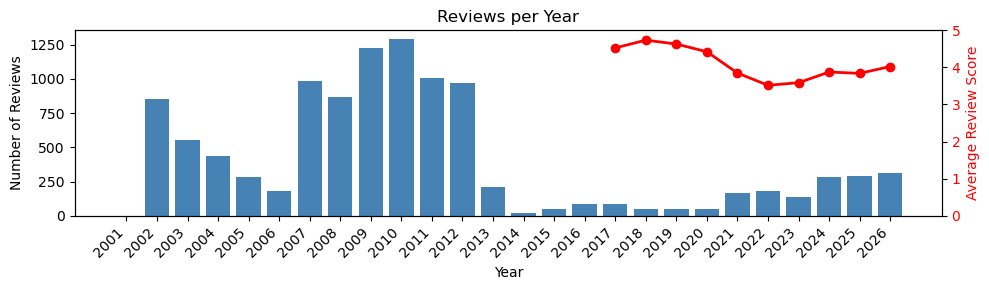

In [17]:
# Plot reviews per year: total count and average rating
yearly_stats = (
    df.assign(year=pd.to_datetime(df["published_on"]).dt.year)
    .groupby("year")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("rating", "mean"),
        rated_count=("rating", lambda s: s.notna().sum()),
    )
    .sort_index()
)

x = range(len(yearly_stats))
years = yearly_stats.index

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.bar(x, yearly_stats["review_count"], color="steelblue", label="Review count")
ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45, ha="right")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Reviews")
ax1.set_title("Reviews per Year")

ax2 = ax1.twinx()
avg_rating = yearly_stats["avg_rating"].where(yearly_stats["rated_count"] > 0)
ax2.plot(x, avg_rating, color="red", marker="o", linewidth=2, label="Avg rating")
ax2.set_ylabel("Average Review Score", color="red")
ax2.set_ylim(0, 5)
ax2.tick_params(axis="y", labelcolor="red")

fig.tight_layout()
plt.show()

## Cleaning Text

In [18]:
# Remove Markdown links ([text](url)) and plain URLs
df["cleaned_text"] = df["text"].str.replace(r"\[([^\]]+)\]\((https?://[^\)]+)\)", r"\1", regex=True)
df["cleaned_text"] = df["cleaned_text"].str.replace(r"https?://[^\s]+", "", regex=True)

# Remove Markdown formatting marks (`, *, ~, >, etc.)
df["cleaned_text"] = df["cleaned_text"].str.replace(r"[*`~>#]", "", regex=True)

# Remove 'end' at the end of the string if present, and remove line breaks
df["cleaned_text"] = df["cleaned_text"].str.replace(r"\bend\b$", "", regex=True)
df["cleaned_text"] = df["cleaned_text"].str.replace(r"[\r\n]+", " ", regex=True).str.strip()

In [26]:
itables.show(df[["text", "cleaned_text"]].sample(2), classes="display compact",)


Loading ITables v2.8.0 from the internet... (need help?)


## Basic Text Analysis

In [27]:
# Add a word count
df["word_count"] = df["cleaned_text"].apply(lambda x: len(str(x).split()))

# Add a character count
df["char_count"] = df["cleaned_text"].apply(lambda x: len(str(x)))

# Add a sentence count
df["sentence_count"] = df["cleaned_text"].apply(lambda x: len(str(x).split(".")))

# Add a sentiment score
df["sentiment_score"] = df["cleaned_text"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Add a sentiment category
df["sentiment_category"] = df["sentiment_score"].apply(lambda x: "positive" if x > 0 else "negative" if x < 0 else "neutral")

In [29]:
itables.show(
    df[["rating", "word_count", "char_count", 
    "sentence_count", "sentiment_score", "sentiment_category"]].sample(5), classes="display compact",)

Loading ITables v2.8.0 from the internet... (need help?)


In [40]:
negative_with_ratings = df[(df["sentiment_category"] == "negative") & (df["rating"].notnull())]
itables.show(negative_with_ratings[["cleaned_text", "rating", "sentiment_score"]].sample(3), classes="display compact")

Loading ITables v2.8.0 from the internet... (need help?)


### Length distributions

In [41]:
length_cols = ["word_count", "char_count", "sentence_count"]

df[length_cols].describe()

,word_count,char_count,sentence_count
count,10631.000000,10631.000000,10631.000000
mean,318.440410,1922.497037,14.795880
std,135.840933,812.267933,7.708342
min,1.000000,1.000000,1.000000
25%,288.000000,1728.000000,12.000000
50%,347.000000,2094.000000,15.000000
75%,381.000000,2322.000000,18.000000
max,5472.000000,31177.000000,441.000000


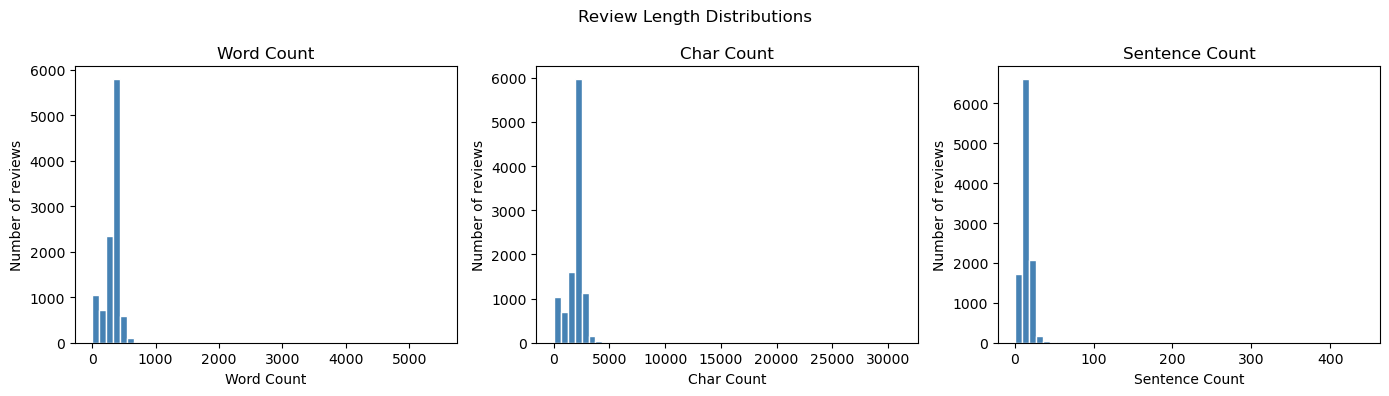

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, length_cols):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Number of reviews")

fig.suptitle("Review Length Distributions")
fig.tight_layout()
plt.show()

In [57]:
min_length = 200
short_reviews = df[df["char_count"] < min_length]
itables.show(short_reviews[["cleaned_text", "char_count"]].sample(5), classes="display compact")

Loading ITables v2.8.0 from the internet... (need help?)


In [59]:
long_reviews = df[df["char_count"] > 200]

In [60]:
long_reviews.to_csv(DATA_DIR / "critique_brainz_reviews_cleaned.csv", index=False)